In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Loading and viewing the data
train_data = pd.read_excel(r"C:\Users\Administrator\Downloads\Flight_Price_resources\Data_Train.xlsx")
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


# Data Cleaning

In [3]:
# Finding the number of missing values per column
train_data.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
# Dropping missing values
train_data.dropna(inplace = True)

In [6]:
train_data.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

## Making time columns into datetime + feature engineering

In [7]:
data = train_data.copy()

In [8]:
# A function that takes a column input and converts all entries in that column to datetime format
def change_into_datetime(col, date_format=None):
    data[col] = pd.to_datetime(data[col], format=date_format, dayfirst=True)

In [9]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [10]:
# Converting departure time, arrival time and journey date columns to datetime, ymd format
for feature in ['Dep_Time', 'Arrival_Time', 'Date_of_Journey']:
    change_into_datetime(feature)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3049815363.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], format=date_format, dayfirst=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3049815363.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col] = pd.to_datetime(data[col], format=date_format, dayfirst=True)


In [11]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [12]:
# Performing feature engineering
# Adding 3 new columns for day, month and year of journey date
data["Journey_day"] = data['Date_of_Journey'].dt.day
data["Journey_month"] = data['Date_of_Journey'].dt.month
data["Journey_year"] = data['Date_of_Journey'].dt.year

In [13]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019


In [14]:
# Function that extracts the hour and minute for a column
# 2 new columns are added to the data frame per feature, one for hour and one for minute
def extract_hour_min(df, col):
    df[col + "_hour"] = df[col].dt.hour
    df[col + "_minute"] = df[col].dt.minute    

In [15]:
extract_hour_min(data, 'Dep_Time')
extract_hour_min(data, 'Arrival_Time')

In [16]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [17]:
# Dropping redundant columns
data.drop(columns = ['Dep_Time', 'Arrival_Time'])

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,2019,19,55,22,25
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,2019,20,45,23,20
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,2019,8,20,11,20
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,2019,11,30,14,10


## Cleaning up 'Duration' column

In [18]:
# Another function needed to extract hour and minute of Duration column since it contains a mixture of strings and integers
def preprocess_duration(x):
    if 'h' not in x:
       x = '0h' + ' ' + x
    elif 'm' not in x:
       x = x + ' ' + '0m'

    return x

In [19]:
data['Duration'] = data['Duration'].apply(preprocess_duration)

In [20]:
data['Duration'][0].split(' ')

['2h', '50m']

In [21]:
int(data['Duration'][0].split(' ')[1][0:-1])

50

In [22]:
data['Duration_hours'] = data['Duration'].apply(lambda x : int(x.split(' ')[0][0:-1]))

In [23]:
data['Duration_mins'] = data['Duration'].apply(lambda x : int(x.split(' ')[1][0:-1]))

In [24]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h 0m,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45


Summary of preprocessing of 'Duration' column:

- preprocess_duration function defined to ensure each entry has both an hour and minute column, prepending '0h ' if hours are missing or ' 0m' if minutes are missing
- Lambda function applied to output of above function to split the duration by space (hour and minute) and converting each to an integer

# Data Analysis

## When do most flights take off?

In [25]:
# Function to determine time category of each flight departure
def flight_dep_time(x):
    if 4 < x <= 8:
        return 'Early morning'
        
    elif 8 < x <= 12:
        return "Morning"

    elif 12 < x <= 16:
        return "Afternoon"

    elif 16 < x <= 20:
        return "Evening"

    elif 20 < x <= 24:
        return "Night"

    else:
        return "Late Night"

<Axes: xlabel='Dep_Time_hour'>

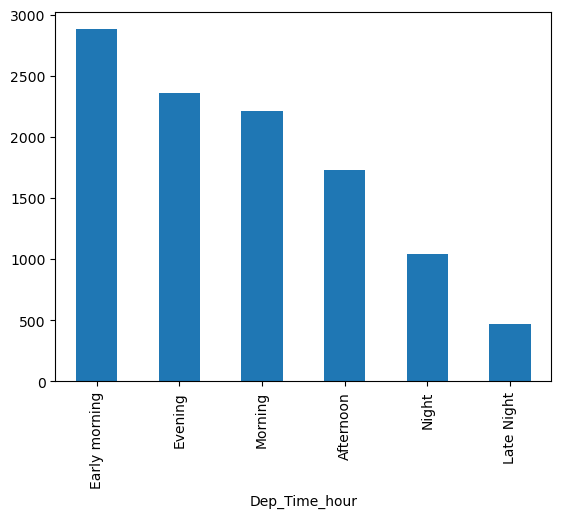

In [26]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind = "bar")

Most flights are in early mornings (4am - 8am) followed by evenings (4pm - 8pm) followed by mornings (8am - 12pm). The least number of flights depart at late night (12am - 4am).

In [27]:
!pip install cufflinks

In [28]:
# Using cufflinks to plot above bar graph in a more interactive way
import plotly
import cufflinks as cf
from cufflinks.offline import go_offline
from plotly.offline import plot, iplot, init_notebook_mode, download_plotlyjs
init_notebook_mode(connected = True)
cf.go_offline()

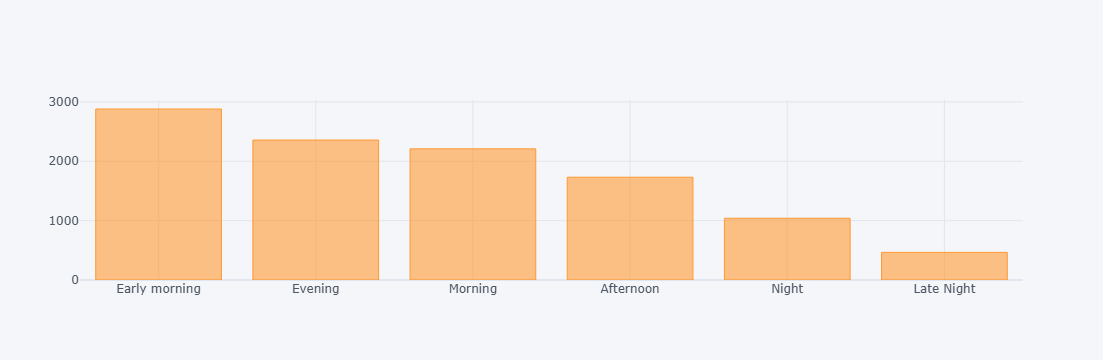

In [29]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().iplot(kind = "bar")

## Impact of Duration on Price

In [30]:
data['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [31]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Duration_hours', 'Duration_mins'],
      dtype='object')

In [32]:
# Adding a column that contains the total duration of each flight by minutes
data['Duration_total_mins'] = data['Duration'].str.replace('h' , '*60').str.replace(' ' , '+').str.replace('m' , '*1').apply(eval)

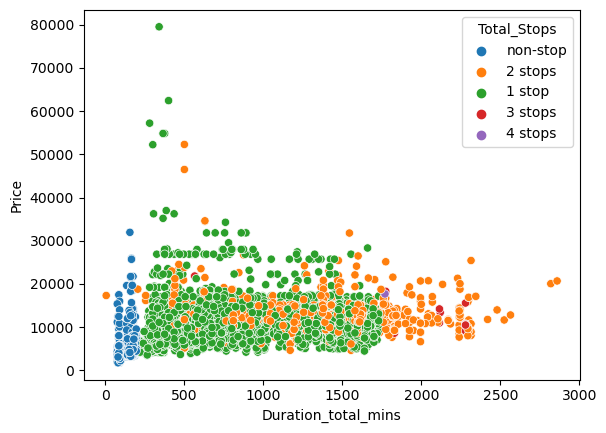

In [33]:
sns.scatterplot(x = 'Duration_total_mins', y = 'Price', data = data, hue = 'Total_Stops')
plt.show()

Overall trend is that duration tends to increase as number of stops increase as expected. Cannot see much pattern of number of stops on price. Linear regression line below shows an upward trend but the outliers seen for 1 stop (> 50000) means the line is not that accurate.

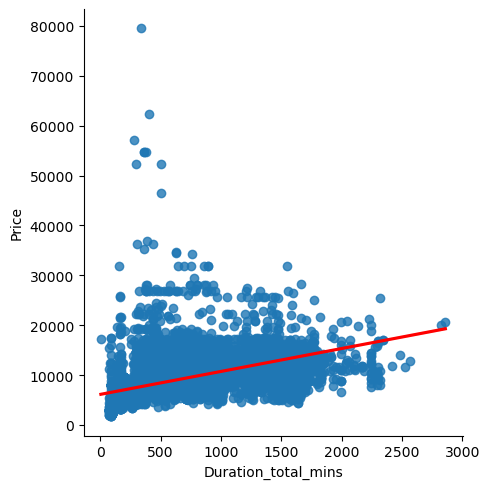

In [34]:
sns.lmplot(x = 'Duration_total_mins', y = 'Price', data = data, line_kws={"color": "red"})
plt.show()

## Airline vs Price

In [35]:
data[data['Airline'] == 'Jet Airways'].groupby('Route').size().sort_values(ascending = False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
BOM → HYD                207
DEL → JAI → BOM → COK    207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
DEL → CCU → BOM → COK      1
BOM → VNS → DEL → HYD      1
BOM → UDR → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → IDR → DEL → HYD      1
BOM → DED → DEL → HYD      1
dtype: int64

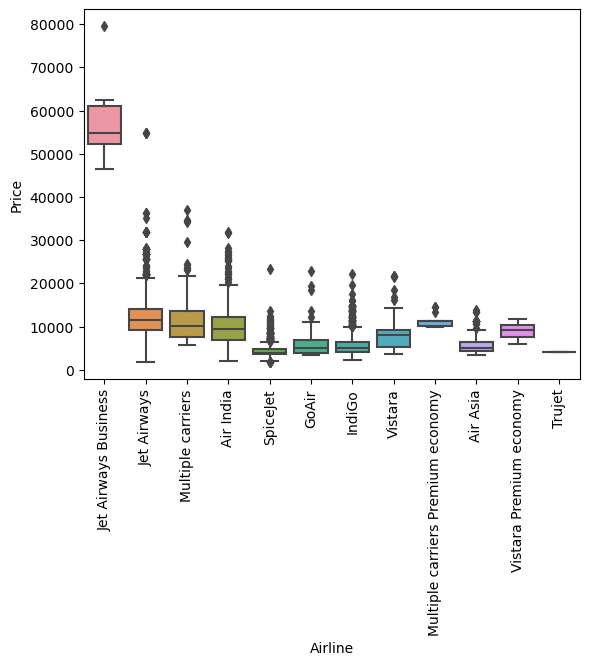

In [36]:
# Boxplot to see distribution of airline prices per airline
sns.boxplot(y = 'Price', x = 'Airline', data = data.sort_values(by = 'Price', ascending = False))
plt.xticks(rotation = "vertical")
plt.show()

Most airlines have somewhat similar airline prices around the 10000 range. Jet Airways Business stands out, having majority of prices in the 50000 to 60000 range.

# Applying feature encoding (Feature engineering)

## One-hot encoding for 'Source'

In [37]:
# Specifying the categorical columns
cat_col = [col for col in data.columns if data[col].dtype == "object"]
cat_col

['Airline',
 'Source',
 'Destination',
 'Route',
 'Duration',
 'Total_Stops',
 'Additional_Info']

In [38]:
# Specifying the numerical columns
num_col = [col for col in data.columns if data[col].dtype != "object"]
num_col

['Date_of_Journey',
 'Dep_Time',
 'Arrival_Time',
 'Price',
 'Journey_day',
 'Journey_month',
 'Journey_year',
 'Dep_Time_hour',
 'Dep_Time_minute',
 'Arrival_Time_hour',
 'Arrival_Time_minute',
 'Duration_hours',
 'Duration_mins',
 'Duration_total_mins']

In [39]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [40]:
# One hot encoding for starting point of flights (creates 5 new columns, 1 for each source)
for sub_category in data['Source'].unique():
    data['Source_' + sub_category] = data['Source'].apply(lambda x : 1 if x == sub_category else 0)

In [41]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,...,1,10,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,...,13,15,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h 0m,2 stops,No info,...,4,25,19,0,1140,0,0,1,0,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,...,23,30,5,25,325,0,1,0,0,0
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,...,21,35,4,45,285,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,2025-02-22 19:55:00,2025-02-22 22:25:00,2h 30m,non-stop,No info,...,22,25,2,30,150,0,1,0,0,0
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,2025-02-22 20:45:00,2025-02-22 23:20:00,2h 35m,non-stop,No info,...,23,20,2,35,155,0,1,0,0,0
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,2025-02-22 08:20:00,2025-02-22 11:20:00,3h 0m,non-stop,No info,...,11,20,3,0,180,1,0,0,0,0
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,2025-02-22 11:30:00,2025-02-22 14:10:00,2h 40m,non-stop,No info,...,14,10,2,40,160,1,0,0,0,0


## Target-guided encoding for 'Airline'

In [42]:
data['Airline'].nunique()

12

In [43]:
data.groupby(['Airline'])['Price'].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4338.284841
Air Asia                              5590.260188
IndiGo                                5673.682903
GoAir                                 5861.056701
Vistara                               7796.348643
Vistara Premium economy               8962.333333
Air India                             9612.427756
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11643.923357
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [44]:
airlines = data.groupby(['Airline'])['Price'].mean().sort_values().index
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [45]:
# Mapping each airline to a number based on increasing price (Trujet is 0, SpiceJet is 1 etc.)
dict_airlines = {key: index for index, key in enumerate(airlines, 0)}

In [46]:
data['Airline'] = data['Airline'].map(dict_airlines)

In [47]:
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h 0m,2 stops,No info,...,4,25,19,0,1140,0,0,1,0,0
3,3,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,...,23,30,5,25,325,0,1,0,0,0
4,3,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,...,21,35,4,45,285,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,2,2019-04-09,Kolkata,Banglore,CCU → BLR,2025-02-22 19:55:00,2025-02-22 22:25:00,2h 30m,non-stop,No info,...,22,25,2,30,150,0,1,0,0,0
10679,7,2019-04-27,Kolkata,Banglore,CCU → BLR,2025-02-22 20:45:00,2025-02-22 23:20:00,2h 35m,non-stop,No info,...,23,20,2,35,155,0,1,0,0,0
10680,10,2019-04-27,Banglore,Delhi,BLR → DEL,2025-02-22 08:20:00,2025-02-22 11:20:00,3h 0m,non-stop,No info,...,11,20,3,0,180,1,0,0,0,0
10681,5,2019-03-01,Banglore,New Delhi,BLR → DEL,2025-02-22 11:30:00,2025-02-22 14:10:00,2h 40m,non-stop,No info,...,14,10,2,40,160,1,0,0,0,0


## Target encoding for 'Destination'

In [48]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [49]:
data['Destination'].replace('New Delhi' , 'Delhi', inplace = True)

In [50]:
data['Destination'].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [51]:
data.groupby(['Destination'])['Price'].mean().sort_values()

Destination
Kolkata       4789.892388
Hyderabad     5059.708752
Delhi         8017.464269
Banglore      9158.389411
Cochin       10540.113536
Name: Price, dtype: float64

In [52]:
destinations = data.groupby(['Destination'])['Price'].mean().sort_values().index
destinations

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='object', name='Destination')

In [53]:
# Same as airlines column, performing the same mapping for flight destinations
dict_destinations = {key: index for index, key in enumerate(destinations, 0)}
dict_destinations

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [54]:
data['Destination'] = data['Destination'].map(dict_destinations)

In [55]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,non-stop,No info,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2 stops,No info,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h 0m,2 stops,No info,...,4,25,19,0,1140,0,0,1,0,0
3,3,2019-05-12,Kolkata,3,CCU → NAG → BLR,2025-02-22 18:05:00,2025-02-22 23:30:00,5h 25m,1 stop,No info,...,23,30,5,25,325,0,1,0,0,0
4,3,2019-03-01,Banglore,2,BLR → NAG → DEL,2025-02-22 16:50:00,2025-02-22 21:35:00,4h 45m,1 stop,No info,...,21,35,4,45,285,1,0,0,0,0


## Label encoding for Total_Stops

In [56]:
data['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [57]:
# Converting entries in Total_Stops to integers
stops = {'non-stop' : 0, '1 stop' : 1, '2 stops' : 2, '3 stops' : 3, '4 stops' : 4}
data['Total_Stops'] = data['Total_Stops'].map(stops)

In [58]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2025-02-22 22:20:00,2025-03-22 01:10:00,2h 50m,0,No info,...,1,10,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,2025-02-22 05:50:00,2025-02-22 13:15:00,7h 25m,2,No info,...,13,15,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,2025-02-22 09:25:00,2025-06-10 04:25:00,19h 0m,2,No info,...,4,25,19,0,1140,0,0,1,0,0


In [59]:
# Dropping redundant columns
data.drop(columns = ['Date_of_Journey', 'Route', 'Duration_total_mins', 'Additional_Info', 'Source', 'Journey_year', 'Dep_Time', 'Arrival_Time', 'Duration'], inplace = True)

In [60]:
data.head()

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,1,6218,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,1,13302,1,3,16,50,21,35,4,45,1,0,0,0,0


In [61]:
data.shape

(10682, 17)

## Dealing with outliers

In [62]:
# Function that plots 2 histograms (one with overlayed distribution) and a boxplot
def plot(df, col):
    fig, (ax1, ax2, ax3) = plt.subplots(3,1)

    sns.distplot(df[col], ax = ax1)
    sns.boxplot(x = df[col], ax = ax2)
    sns.distplot(df[col], ax = ax3, kde = False)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3332168238.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3332168238.py:6: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms

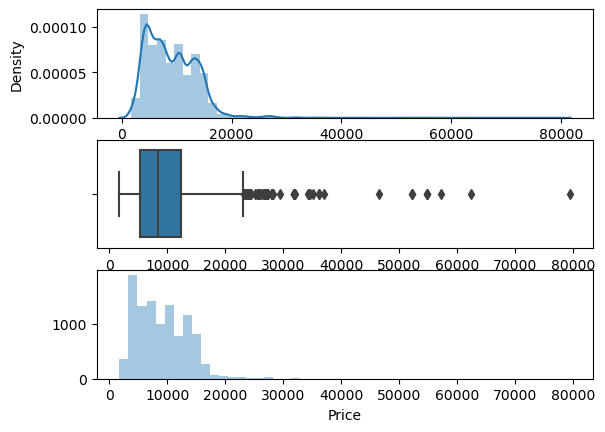

In [63]:
plot(data, 'Price')

Outliers are obvious from all 3 plots, looking at the boxplot we can see quite a lot of prices beyond the IQR

In [64]:
q1 = data['Price'].quantile(0.25)
q3 = data['Price'].quantile(0.75)

iqr = q3-q1

max = q3 + 1.5 * iqr
min = q1 - 1.5 * iqr

In [65]:
min

-5367.0

In [66]:
print([price for price in data['Price'] if price > max or price < min])

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [67]:
# Excluded all entries where price is above 35000, taking into account the iqr and what the theoretical min and max should be
data['Price'] = np.where(data['Price'] >= 35000 , data['Price'].median(), data['Price'])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3332168238.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14032\3332168238.py:6: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms

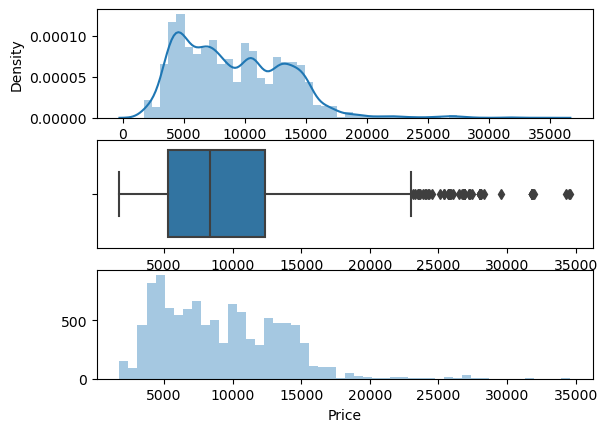

In [68]:
plot(data, 'Price')

## Feature selection for Machine Learning

In [69]:
# Creating feature and target variables
X = data.drop(['Price'], axis = 1)
y = data['Price']

In [70]:
from sklearn.feature_selection import mutual_info_regression

In [71]:
# Calculates dependency between each feature variable and the target variable
# Takes linear and non-linear relationships into account
imp_features = mutual_info_regression(X,y)
imp_features

array([0.96373235, 1.00200133, 0.79236044, 0.23282753, 0.63551684,
       0.33703945, 0.25532359, 0.39822844, 0.34982305, 0.47053116,
       0.34526695, 0.38867727, 0.45579728, 0.51257507, 0.13857651,
       0.20138719])

In [72]:
imp_df = pd.DataFrame(imp_features, index = X.columns)
imp_df.columns = ['importance']
imp_df

,importance
Airline,0.963732
Destination,1.002001
Total_Stops,0.792360
Journey_day,0.232828
Journey_month,0.635517
Dep_Time_hour,0.337039
Dep_Time_minute,0.255324
Arrival_Time_hour,0.398228
Arrival_Time_minute,0.349823
Duration_hours,0.470531


In [73]:
imp_df.sort_values(by = "importance", ascending = False)

,importance
Destination,1.002001
Airline,0.963732
Total_Stops,0.792360
Journey_month,0.635517
Source_Delhi,0.512575
Duration_hours,0.470531
Source_Kolkata,0.455797
Arrival_Time_hour,0.398228
Source_Banglore,0.388677
Arrival_Time_minute,0.349823


From the table, Destination, Airline and Total_Stops seem to be the most important features towards predicting Price

In [74]:
data.head()

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897.0,24,3,22,20,1,10,2,50,1,0,0,0,0
1,7,3,2,7662.0,1,5,5,50,13,15,7,25,0,1,0,0,0
2,10,4,2,13882.0,9,6,9,25,4,25,19,0,0,0,1,0,0
3,3,3,1,6218.0,12,5,18,5,23,30,5,25,0,1,0,0,0
4,3,2,1,13302.0,1,3,16,50,21,35,4,45,1,0,0,0,0


# Modelling

## Random Forest

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
# Splitting the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [77]:
from sklearn.ensemble import RandomForestRegressor

In [78]:
# Fitting the Random Forest on training data
random_forest = RandomForestRegressor()
random_forest.fit(X_train, y_train)

RandomForestRegressor()

In [79]:
# Predicting for testing set
y_pred = random_forest.predict(X_test)
y_pred

array([16922.6       ,  5446.91      ,  8920.01      , ...,
        6397.39      , 12850.54666667, 13063.46340476])

In [80]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [81]:
# Evaluating model, comparing predictions to actual values
r2_score(y_test, y_pred)

0.8123527740588322

## Automating ML models

In [82]:
# Function to calculate Mean Average Prediction Error
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [83]:
mape(y_test, y_pred)

13.137056400166767

In [84]:
# Automating the whole model fitting, predicting, testing and evaluating process under one function
# Simply input the ml model and output gives training score, predictions, r^2 score, MAE, MSE, RMSE, MAPE and a histogram of the difference in values 
# between testing and predicted values
def predict(ml_model):
    model = ml_model.fit(X_train, y_train)
    print('Training score: {}'.format(model.score(X_train, y_train)))
    y_prediction = model.predict(X_test)
    print('Predictions are: {}'.format(y_prediction))
    print('\n')
    r2 = r2_score(y_test, y_prediction)
    print('r2 score: {}'.format(r2))
    print('MAE: {}'.format(mean_absolute_error(y_test, y_prediction)))
    print('MSE: {}'.format(mean_squared_error(y_test, y_prediction)))
    print('RMSE: {}'.format(np.sqrt(mean_squared_error(y_test, y_prediction))))
    print('MAPE: {}'.format(mape(y_test, y_prediction)))
    sns.displot(y_test - y_prediction)
    

### Random Forest

Training score: 0.9506349549163268
Predictions are: [16840.14        5350.88        8871.72       ...  6561.63
 12738.09166667 13314.406     ]


r2 score: 0.8111535478822116
MAE: 1195.3113522507495
MSE: 3802478.687945936
RMSE: 1949.9945353630958
MAPE: 13.214392067903653


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



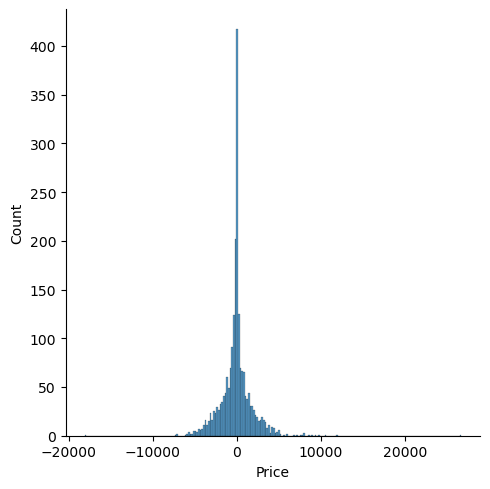

In [85]:
predict(RandomForestRegressor())

### Decision Tree

In [86]:
from sklearn.tree import DecisionTreeRegressor

Training score: 0.9651196669167478
Predictions are: [16840.  4959.  9397. ...  6152. 13339. 14335.]


r2 score: 0.6970812479920938
MAE: 1388.9849555451565
MSE: 6099357.895115816
RMSE: 2469.6878132905413
MAPE: 15.307163829798656


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



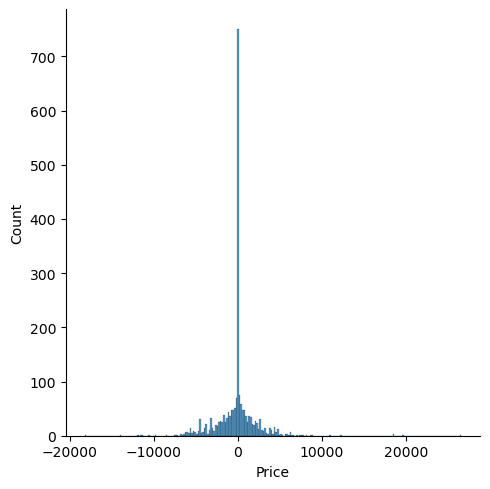

In [87]:
predict(DecisionTreeRegressor())

### Linear Regression

In [88]:
from sklearn.linear_model import LinearRegression

Training score: 0.5961933134025743
Predictions are: [12707.72292395  8099.81841933  8983.58100117 ...  6682.61927088
 11440.00389928 11196.56952918]


r2 score: 0.5656622155341036
MAE: 2035.1686664607819
MSE: 8745518.649040364
RMSE: 2957.2823079713517
MAPE: 24.658590994860567


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



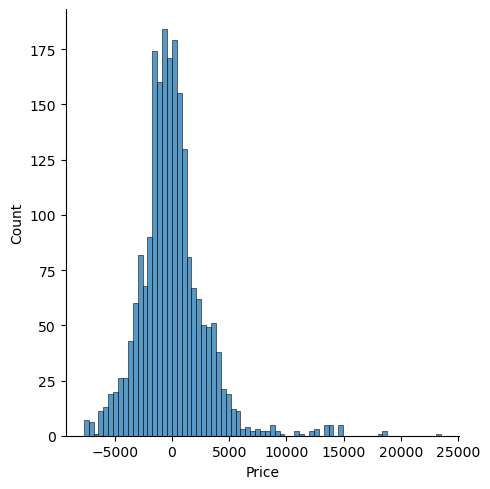

In [89]:
predict(LinearRegression())

In [1]:
# Attempt to use Stochastic Gradient Descent 

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

In [92]:
X = data.drop(['Price'], axis = 1)
y = data['Price']

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
sgd_model = SGDRegressor(max_iter=5000, tol=1e-5, learning_rate='optimal', eta0=0.001, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

SGDRegressor(eta0=0.001, learning_rate='optimal', max_iter=5000,
             random_state=42, tol=1e-05)

In [96]:
y_pred = sgd_model.predict(X_test_scaled)
y_pred

array([11106.55606942,  9371.53747519,  8434.31203253, ...,
        7600.59187964, 10326.68282794, 11195.72241995])

In [97]:
print("R² Score:", r2_score(y_test, y_pred))

R² Score: 0.5253951249191912


### KNN

In [98]:
from sklearn.neighbors import KNeighborsClassifier

Training score: 0.5236980690462258
Predictions are: [16840.  4959.  7927. ...  6152.  5192. 10703.]


r2 score: 0.392869186425993
MAE: 2070.018717828732
MSE: 12224756.95741694
RMSE: 3496.3919913843956
MAPE: 19.786175838905365


C:\Users\Administrator\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



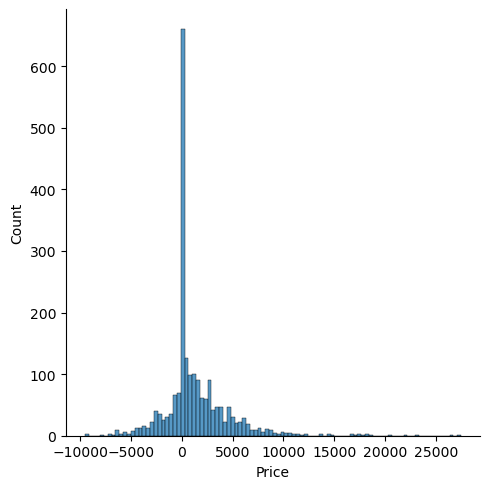

In [99]:
predict(KNeighborsClassifier(3))

In [110]:
# Summarising R^2 scores of all different models
r2_scores = {
    'Random Forest': 0.811,
    'Decision Tree': 0.697,
    'Linear Regression': 0.566,
    'SGD' : 0.525,
    'kNN': 0.393
}

r2_table = pd.DataFrame(r2_scores.items(), columns=['Algorithm', 'R2 Score'])
r2_table

,Algorithm,R2 Score
0,Random Forest,0.811
1,Decision Tree,0.697
2,Linear Regression,0.566
3,SGD,0.525
4,kNN,0.393


Random Forest performed the best not just in terms of R^2 but also looking at the histogram, we have strong centrality around 0 and little variation, indicating good performance.

## Hypertuning ML models

In [100]:
from sklearn.model_selection import RandomizedSearchCV

In [101]:
reg_rf = RandomForestRegressor()

In [102]:
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 800, num = 8)]
max_features = ["sqrt"]
max_depth = [int(x) for x in np.linspace(start = 5, stop = 50, num = 10)]
min_samples_split = [2, 5, 10, 15, 25, 50]
min_samples_leaf = [1, 2, 4, 10]

In [103]:
# Using randomised search cross validation to find the best RF parameters (n_estimators, max_depth, min_samples_split, min_samples_leaf)
random_grid = {
    "n_estimators" : n_estimators , 
    "max_features" : max_features , 
    "max_depth" : max_depth ,
    "min_samples_split" : min_samples_split,
    "min_samples_leaf" : min_samples_leaf,
    "bootstrap" : [True, False]
}
random_grid

{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
 'max_features': ['sqrt'],
 'max_depth': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
 'min_samples_split': [2, 5, 10, 15, 25, 50],
 'min_samples_leaf': [1, 2, 4, 10],
 'bootstrap': [True, False]}

In [104]:
rf_random = RandomizedSearchCV(
    estimator = reg_rf, 
    param_distributions = random_grid, 
    n_iter = 25,
    cv = 3,
    n_jobs = -1,
    verbose = 2    
)

In [105]:
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_iter=25,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [5, 10, 15, 20, 25, 30, 35,
                                                      40, 45, 50],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2, 4, 10],
                                        'min_samples_split': [2, 5, 10, 15, 25,
                                                              50],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800]},
                   verbose=2)

In [106]:
rf_random.best_params_

{'n_estimators': 700,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 45,
 'bootstrap': False}

In [107]:
rf_random.best_estimator_

RandomForestRegressor(bootstrap=False, max_depth=45, max_features='sqrt',
                      min_samples_leaf=4, min_samples_split=10,
                      n_estimators=700)

In [108]:
rf_random.best_score_

0.8090205181670597

Surprisingly even after Randomised Search CV R^2 is lower than original RF model (0.811)

In [2]:
# Trying halving Random Search CV

In [151]:
from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import HalvingRandomSearchCV

rf_halving = HalvingRandomSearchCV(
    estimator=reg_rf, 
    param_distributions=random_grid, 
    factor=3, 
    cv=3, 
    verbose=2, 
    n_jobs=-1
)

rf_halving.fit(X_train, y_train)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 6
max_resources_: 8545
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1424
n_resources: 6
Fitting 3 folds for each of 1424 candidates, totalling 4272 fits


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning:

One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]



----------
iter: 1
n_candidates: 475
n_resources: 18
Fitting 3 folds for each of 475 candidates, totalling 1425 fits


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning:

One or more of the test scores are non-finite: [        nan         nan         nan ... -1.11815753 -1.74375733
 -1.74375733]



----------
iter: 2
n_candidates: 159
n_resources: 54
Fitting 3 folds for each of 159 candidates, totalling 477 fits


...

----------
iter: 5
n_candidates: 6
n_resources: 1458
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning:

One or more of the test scores are non-finite: [       nan        nan        nan ... 0.7043564  0.70279859 0.70125306]



----------
iter: 6
n_candidates: 2
n_resources: 4374
Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning:

One or more of the test scores are non-finite: [       nan        nan        nan ... 0.70125306 0.77136731 0.77215204]



HalvingRandomSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                      param_distributions={'bootstrap': [True, False],
                                           'max_depth': [5, 10, 15, 20, 25, 30,
                                                         35, 40, 45, 50],
                                           'max_features': ['sqrt'],
                                           'min_samples_leaf': [1, 2, 4, 10],
                                           'min_samples_split': [2, 5, 10, 15,
                                                                 25, 50],
                                           'n_estimators': [100, 200, 300, 400,
                                                            500, 600, 700,
                                                            800]},
                      verbose=2)

In [152]:
rf_halving.best_params_

{'n_estimators': 800,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 35,
 'bootstrap': False}

In [153]:
rf_halving.best_score_

0.7721520437292596

Even after attempting halving random search CV, model performance is worse than original RF model